### Loading Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots appear inside the notebook
%matplotlib inline

### Loading Data

In [3]:
df = pd.read_csv('Crimes-2024.csv')  # adjust filename to match yours
print(df.shape)  # tells you how many rows & columns
df.head()        # shows first 5 rows

(259018, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,5,43,14,1186817.0,1860189.0,2024,11/02/2025 03:41:09 PM,41.771470,-87.590742,POINT (-87.59074212 41.771470188)
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,...,3,38,26,1179661.0,1873623.0,2024,05/17/2025 03:40:52 PM,41.808501,-87.616563,POINT (-87.616562762 41.808500903)
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,...,18,70,04B,1145740.0,1853048.0,2024,11/02/2025 03:41:09 PM,41.752749,-87.741498,POINT (-87.741497836 41.752748627)
3,13709164,JJ101392,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,20,42,14,1184362.0,1861188.0,2024,11/02/2025 03:41:09 PM,41.774269,-87.599710,POINT (-87.599709962 41.774269351)
4,13707823,JJ100020,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,False,False,...,29,25,08B,1137458.0,1907694.0,2024,05/17/2025 03:40:52 PM,41.902858,-87.770537,POINT (-87.770536741 41.902858242)


Basic Exploration

In [4]:
# What columns do we have?
print(df.columns.tolist())

# Any missing data?
print(df.isnull().sum())

# What types of crimes exist?
print(df['Primary Type'].value_counts().head(20))

['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']
ID                         0
Case Number                0
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description    1120
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       0
Community Area             0
FBI Code                   0
X Coordinate            1471
Y Coordinate            1471
Year                       0
Updated On                 0
Latitude                1471
Longitude               1471
Location                1471
dtype: int64
Primary Type
THEFT                               60529
BATTERY              

### Cleaning Data

In [6]:
# Drop rows with missing location data
df = df.dropna(subset=['Latitude', 'Longitude', 'Community Area'])

# Convert date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and hour for analysis
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Date'].dt.hour

print("Clean dataset shape:", df.shape)

Clean dataset shape: (257547, 24)


### Visualizations

### Top 10 Crime Types in Chicago

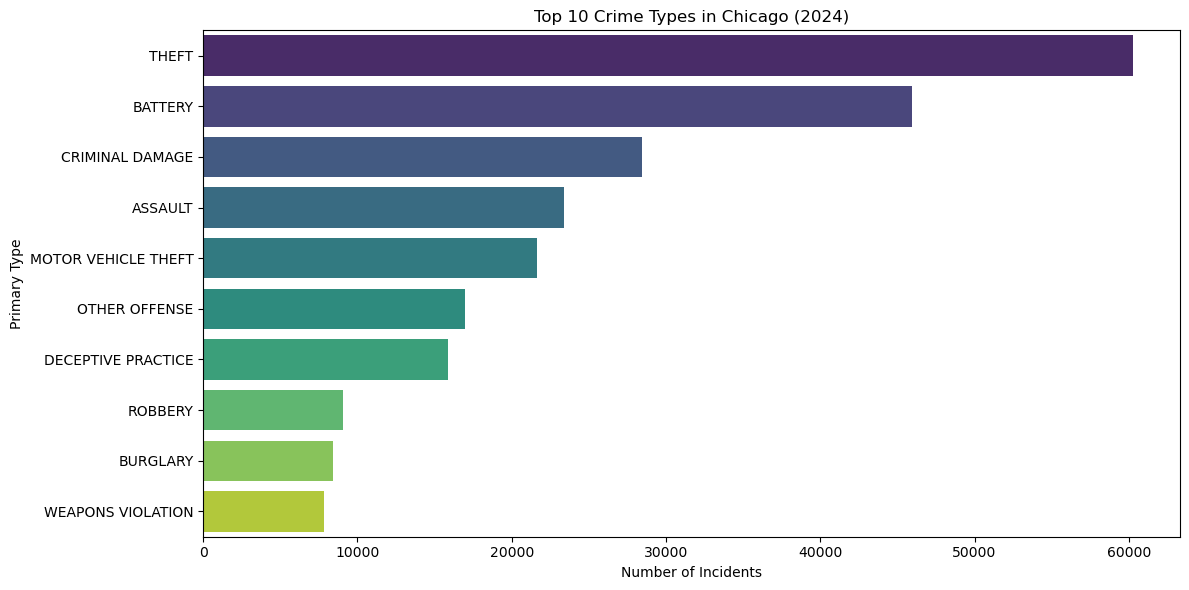

In [9]:
top_crimes = df['Primary Type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, hue=top_crimes.index, palette='viridis', legend=False)
plt.title('Top 10 Crime Types in Chicago (2024)')
plt.xlabel('Number of Incidents')
plt.tight_layout()
plt.savefig('top_crimes.png')  # saves the chart
plt.show()

### Crime by Month (Seasonality)

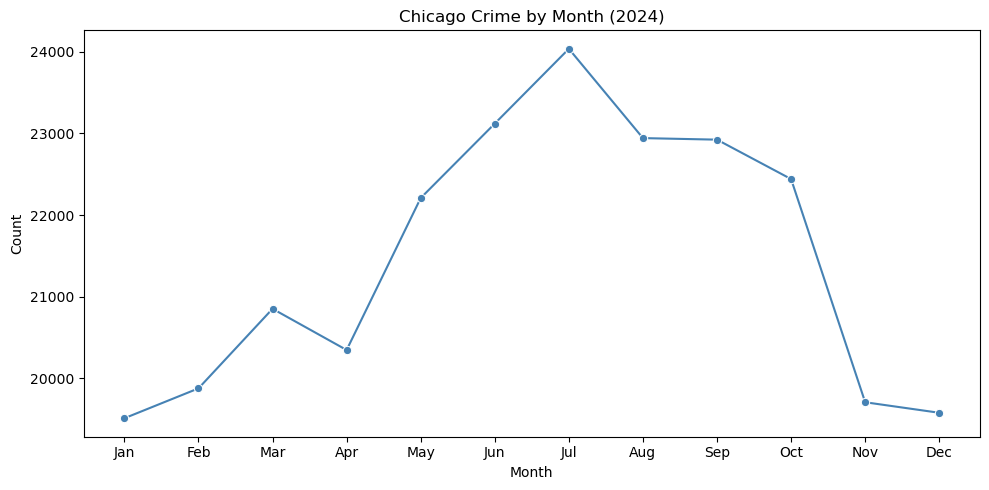

In [10]:
monthly = df.groupby('Month').size().reset_index(name='Count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x='Month', y='Count', marker='o', color='steelblue')
plt.title('Chicago Crime by Month (2024)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('crime_by_month.png')
plt.show()

### Crime by Hour of the Day

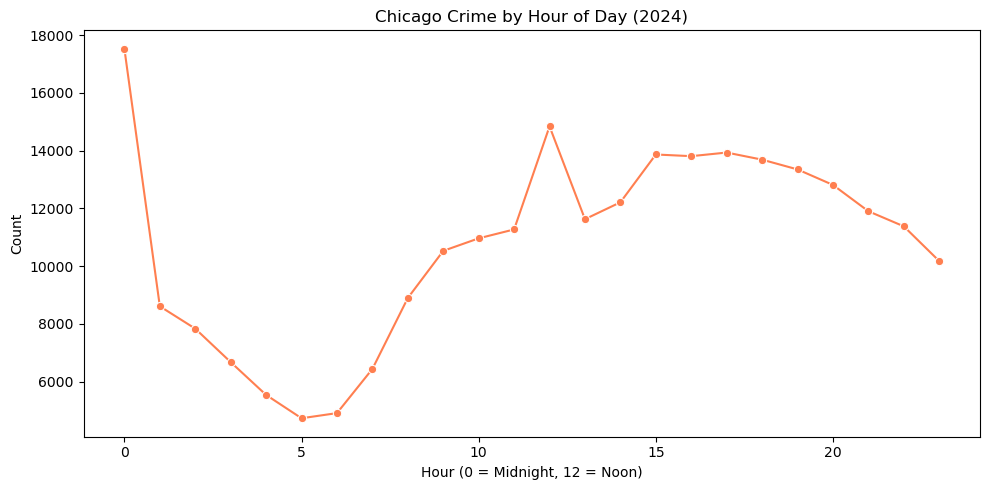

In [11]:
hourly = df.groupby('Hour').size().reset_index(name='Count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly, x='Hour', y='Count', marker='o', color='coral')
plt.title('Chicago Crime by Hour of Day (2024)')
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.tight_layout()
plt.savefig('crime_by_hour.png')
plt.show()

### Analysis

- Theft and battery are the most common crime types by far
- Crime peaks in summer months (June–August), likely due to more 
  outdoor activity
- The highest crime hours are between 6pm–11pm, with a secondary 
  spike at midnight